# <span style="color:red;">Lab5_qLearning_Pravin Oli, Gebrecherkos Gebreslassie</span>

# **Robot Learning – Reinforcement Learning**

The goal of this practical exercise is to implement a Reinforcement Learning algorithm to learn a policy that moves a robot to a goal position. The algorithm is the Q-learning algorithm.

## The Problem
The problem consists in finding the goal in a finite 2D environment that is closed and contains some obstacles.

**States and actions:** The size of the environment is 20x14=280 states. The robot can only do 4 different actions: {←, ↑, →, ↓} (not diagonal movements!). Therefore the size of the Q function will be 280x4=1120 cells.

**Dynamics:** The robot can be located in any free cell (not in the obstacle cells!). The function that describes the dynamics is very simple: the robot will move ONE cell per iteration to the direction of the action that we select, unless there is an obstacle or the wall in front of it, in which case it will
stay in the same position.

**Reinforcement function:** Since the goal is to reach the goal position as fast as possible, the reinforcement function will give -1 in all cells except in the goal cell, where the reward will be +1. The cell that contains the goal is (3,17).

# <span style="color:red;">Part1 Q learning Implementation on Given Map</span>

## Data

Next you have the map that will be used as the environment for the Q-learning algorithm:

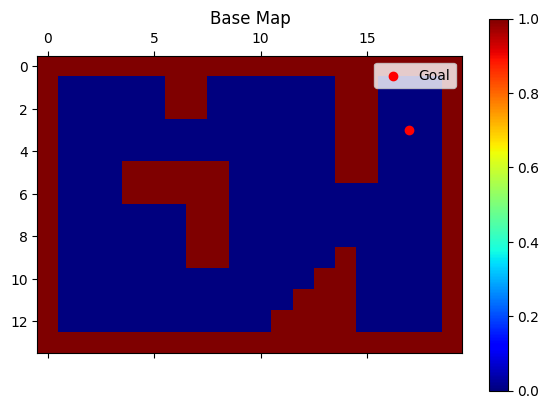

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import random

# Proposed Map
map=[
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
[1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1],
[1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1],
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1],
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1],
[1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1],
[1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
[1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
[1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
[1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1],
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1],
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1],
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1],
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]


# Convert Map 2D array to Numpy array
grid_map = np.array(map)
goal =(3,17)

# Show grid map
plt.matshow(grid_map, cmap = "jet")
plt.title('Base Map')
plt.colorbar()

# Plot the goal point
plt.scatter(goal[1], goal[0], color="red", label="Goal")
plt.legend()
plt.show()

## Algorithm

In order to implement the Q-learning algorithm, you should follow the next pseudocode:

```verbatim
Initialize Q(s,a) to 0 or random
For n episodes:
    Initialize s randomly in any free cell
    repeat:
        Choose action 'a' following epsilon-greedy policy
        Take action a, observe r and s'
        Q(s,a) <- Q(s,a) + alpha * (r + gamma * max_a Q(s',a)) - Q(s,a)
        s <- s'
    until the episode terminates
endFor
```

You will have to set several parameters experimentally: n, m, epsilon, alpha and gamma.

## Environment

In the environment class, you set the possible actions, the rewards obtained depending of those actions and the state of the agent after the action is applied.

You have to fill the empty functions following the previous pseudocode.

In [9]:
class MapEnv:
    def __init__(self, map, goal, max_steps):
        self.map = np.array(map)
        self.current_state = None
        self.goal = np.array(goal, dtype=np.int32)  # Ensure goal is a NumPy array
        self.actions = 4  # 0 = up, 1 = down, 2 = left, 3 = right
        self.steps = 0
        self.max_steps = max_steps
        if self.map[self.goal[0], self.goal[1]] != 0:
            raise ValueError("Goal position is an obstacle")


    def reset(self):
        # Start the agent in a random free cell
        free_cells = np.argwhere(self.map == 0)
        self.current_state = free_cells[np.random.choice(len(free_cells))]
        self.steps = 0
        return tuple(self.current_state)
    
    def step(self, action):
        # Define movement directions
        moves = {
            0: (-1, 0),  # up
            1: (1, 0),   # down
            2: (0, -1),  # left
            3: (0, 1)    # right
        }

        # Get the next state
        move = moves[action]
        next_state = (self.current_state[0] + move[0], self.current_state[1] + move[1])

        # Check boundaries and obstacles
        if (0 <= next_state[0] < self.map.shape[0] and
            0 <= next_state[1] < self.map.shape[1] and
            self.map[next_state[0], next_state[1]] == 0):
            self.current_state = next_state

        self.steps += 1

        # Check if the goal is reached or max steps exceeded
        done = np.array_equal(self.current_state, self.goal) or self.steps >= self.max_steps
        reward = 1 if np.array_equal(self.current_state, self.goal) else -0.1

        return tuple(self.current_state), reward, done

    def get_state(self):
        return tuple(self.current_state)

    def render(self, i=0):
        plt.matshow(self.map, cmap="jet")
        plt.title('Map')
        plt.colorbar()
        plt.scatter(self.current_state[1], self.current_state[0], c='r')
        plt.scatter(self.goal[1], self.goal[0], c='g')
        plt.savefig(f"q_learning_{i:04}.png", dpi=300)
        plt.show()

## QLearning algorithm

QLearning class creates and trains the policy at every episode using the information provided by the environment. After the training is over, the optimal policy and the value function are obtained.

As in the MapEnv class, you have to fill the empty functions following the previous pseudocode.

In [10]:
class QLearning:
    def __init__(self, env, alpha, gamma, epsilon, n_episodes):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.n_episodes = n_episodes
        self.Q = np.random.rand(env.map.shape[0], env.map.shape[1], env.actions)

    def epsilon_greedy_policy(self, s, epsilon):
        # Epsilon-greedy policy: choose a random action with probability epsilon
        if random.uniform(0, 1) < epsilon:
            return random.choice(range(self.env.actions))
        else:
            return np.argmax(self.Q[s[0], s[1]])

    def episode(self, alpha, epsilon):
        # Episode execution: generate actions with epsilon-greedy policy, take steps, and update Q-values
        total_reward = 0
        state = self.env.reset()
        done = False

        while not done:
            action = self.epsilon_greedy_policy(state, epsilon)
            next_state, reward, done = self.env.step(action)

            # Q-learning update rule
            best_next_action = np.argmax(self.Q[next_state[0], next_state[1]])
            self.Q[state[0], state[1], action] += alpha * (
                reward + self.gamma * self.Q[next_state[0], next_state[1], best_next_action] - self.Q[state[0], state[1], action]
            )

            state = next_state
            total_reward += reward

        return total_reward

    def train(self, n_episodes, check_every_n=100):
        """Execute n_episodes and every `check_every_n` episodes print the average reward and store it.
           As the initial position is random, this number will not be super stable..."""
        rewards = []
        for episode in range(n_episodes):
            total_reward = self.episode(self.alpha, self.epsilon)
            rewards.append(total_reward)

            if (episode + 1) % check_every_n == 0:
                avg_reward = np.mean(rewards[-check_every_n:])
                print(f"Episode {episode + 1}/{n_episodes}, Average Reward: {avg_reward:.2f}")

        return rewards

    def get_optimal_policy(self):
        """Once training is done, retrieve the optimal policy from Q(s,a)."""
        policy = np.zeros((self.env.map.shape[0], self.env.map.shape[1]), dtype=np.int32)
        for i in range(self.env.map.shape[0]):
            for j in range(self.env.map.shape[1]):
                if self.env.map[i, j] == 0:  # Only compute for free cells
                    policy[i, j] = np.argmax(self.Q[i, j])
                else:
                    policy[i, j] = -1  # Indicate obstacle
        return policy

    def value_function(self):
        """Once training is done, retrieve the optimal value function from Q(s,a)."""
        v = np.max(self.Q, axis=2)
        v[self.env.map == 1] = -np.inf
        return v

## Training

For the training you need to choose some parameters experimentally. Test different values to see how the training results change.

Parameters:

* **alpha**: learning rate of the algorithm
* **gamma**: discount factor of the algorithm
* **epsilon**: random action probability
* **n_episodes**: number of episode repetitions
* **max_steps**: maximum number of iterations per episode (in Environment class)

Episode 100/10000, Average Reward: -26.89
Episode 200/10000, Average Reward: -8.83
Episode 300/10000, Average Reward: -4.69
Episode 400/10000, Average Reward: -3.45
Episode 500/10000, Average Reward: -2.91
Episode 600/10000, Average Reward: -1.96
Episode 700/10000, Average Reward: -2.01
Episode 800/10000, Average Reward: -2.04
Episode 900/10000, Average Reward: -1.43
Episode 1000/10000, Average Reward: -1.55
Episode 1100/10000, Average Reward: -1.31
Episode 1200/10000, Average Reward: -1.06
Episode 1300/10000, Average Reward: -0.95
Episode 1400/10000, Average Reward: -0.98
Episode 1500/10000, Average Reward: -0.97
Episode 1600/10000, Average Reward: -0.83
Episode 1700/10000, Average Reward: -0.53
Episode 1800/10000, Average Reward: -0.69
Episode 1900/10000, Average Reward: -0.79
Episode 2000/10000, Average Reward: -0.71
Episode 2100/10000, Average Reward: -0.79
Episode 2200/10000, Average Reward: -0.75
Episode 2300/10000, Average Reward: -0.56
Episode 2400/10000, Average Reward: -0.68


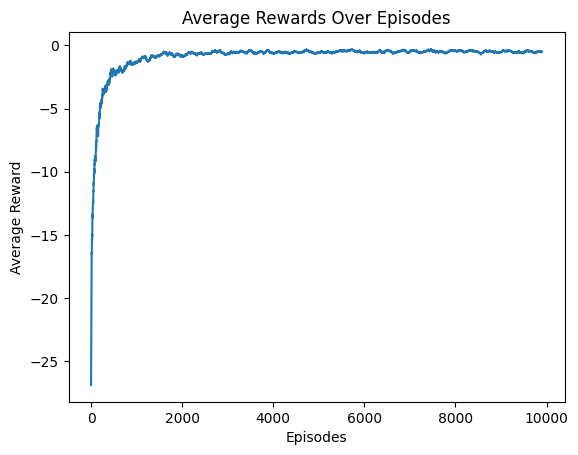

In [ ]:
# Create an environment and a QLearning agent to learn it. Plot the averaged rewards stored.
...

# Training and testing parameters
alpha = 0.1
gamma = 0.9
epsilon = 0.1
#epsilon = max(0.01, epsilon * 0.995)  # Decay factor
n_episodes = 10000
max_steps = 1000

env = MapEnv(grid_map, goal, max_steps)
agent = QLearning(env, alpha, gamma, epsilon, n_episodes)

# Train the agent
rewards = agent.train(n_episodes)

# Plot averaged rewards
plt.plot(np.convolve(rewards, np.ones(100)/100, mode='valid'))
plt.title("Average Rewards Over Episodes")
plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.show()

## Plot value function and optimal policy

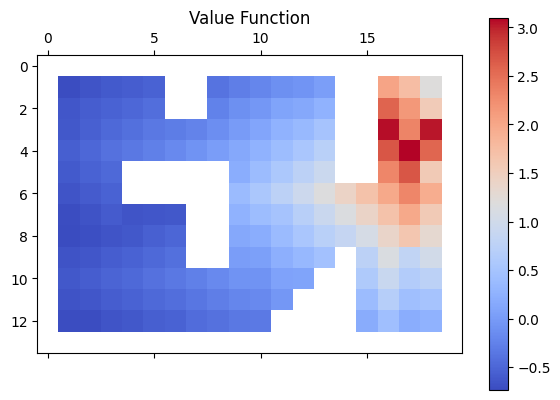

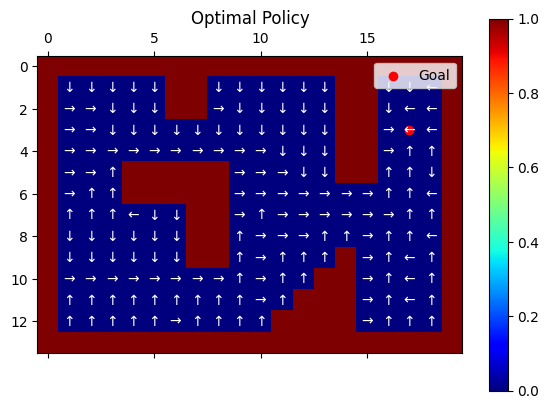

In [12]:
# Plot the value function (see included figure)
...
# Plot value function
value_function = agent.value_function()
plt.matshow(value_function, cmap="coolwarm")
plt.colorbar()
plt.title("Value Function")
plt.show()


# Plot policy (see included figure)
...
# Plot optimal policy on the map
optimal_policy = agent.get_optimal_policy()
policy_arrows = {0: "↑", 1: "↓", 2: "←", 3: "→"}

plt.matshow(grid_map, cmap="jet")
for i in range(optimal_policy.shape[0]):
    for j in range(optimal_policy.shape[1]):
        if optimal_policy[i, j] != -1:  # Not an obstacle
            plt.text(j, i, policy_arrows[optimal_policy[i, j]], ha='center', va='center', color='white')
plt.title("Optimal Policy")
plt.colorbar()
plt.scatter(goal[1], goal[0], color="red", label="Goal")
plt.legend()
plt.show()

## Test current Policy

Once the training is over, we can see what the robot has learnt to do. You can test it with other goal positions and other maps, to see of the policy is able to adapt to other situations.

In [13]:
from IPython.display import HTML
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def generate_animation(env, optimal_policy, goal):
    """
    Generates an animation showing the agent solving the environment using the optimal policy.
    
    Args:
        env: The environment instance.
        optimal_policy: A 2D array of the optimal policy.
        goal: The coordinates of the goal state (row, col).
    
    Returns:
        HTML: An HTML animation object.
    """
    fig, ax = plt.subplots()

    # Initialize the environment
    state = env.reset()
    path = [state]  # Track the path taken by the agent
    done = False

    # Generate the path following the optimal policy
    while not done:
        action = optimal_policy[state[0], state[1]]
        next_state, _, done = env.step(action)
        path.append(next_state)
        state = next_state

    def update(frame):
        """Update function for each frame in the animation."""
        ax.clear()
        ax.matshow(env.map, cmap="jet")
        ax.scatter(goal[1], goal[0], c='r', label="Goal")
        ax.scatter(path[frame][1], path[frame][0], c='g', label="Agent")
        ax.set_title("Agent Solving the Maze")
        ax.legend()
        ax.set_xticks([])
        ax.set_yticks([])

        # Overlay the optimal policy arrows
        for i in range(optimal_policy.shape[0]):
            for j in range(optimal_policy.shape[1]):
                if optimal_policy[i, j] != -1:  # Not an obstacle
                    ax.text(j, i, policy_arrows[optimal_policy[i, j]], ha='center', va='center', color='white')

    ani = animation.FuncAnimation(fig, update, frames=len(path), interval=500, repeat=False)
    plt.close(fig)  # Prevent the static plot from displaying
    return HTML(ani.to_jshtml())

# Generate the animation
animation_html = generate_animation(env, optimal_policy, goal)
animation_html

# <span style="color:red;">Part2 New Maps with user selection 

1. There are two maps . Those maps can be selected by entering 1 or 2 in user interface option.
2. The goal position is also user input.
3. Parameters is als user input

Just play by tuining parameters, choosing different goals for different maps.</span>


## Other environemnts

Create a new map (min size 15 x 15).

Answer:

* The policy you have just learned is able to solve this map?</p>
<span style="color:red;"> Yes, the learned policy can solve all the maps given and created below.

* If not, the algorithm you have implemented is able to learn a new policy to solve this map? Demonstrate one or the other

In [14]:
def display_map(map_choice):
    """Display the selected map and get the goal position."""
    if map_choice == 1:
        # Map 1
        map = np.array([
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
            [1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1],
            [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
            [1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1],
            [1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1],
            [1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
            [1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
        ])
    elif map_choice == 2:
        # Map 2
        map = np.array([
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1],
            [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1],
            [1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1],
            [1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1],
            [1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1],
            [1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1],
            [1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
            [1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1],
            [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1],
            [1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
        ])
    else:
        raise ValueError("Invalid map choice")

    # Input the goal position
    while True:
        try:
            goal_x = int(input("Enter the goal's x-coordinate (row index): "))
            goal_y = int(input("Enter the goal's y-coordinate (column index): "))
            if (0 <= goal_x < map.shape[0]) and (0 <= goal_y < map.shape[1]):
                if map[goal_x, goal_y] == 0:
                    goal = (goal_x, goal_y)
                    break
                else:
                    print("Invalid: You have chosen the goal on an obstacle. Please re-enter.")
            else:
                print("The goal is out of bounds. Please re-enter.")
        except ValueError:
            print("Invalid input. Please enter integer values.")

    # Display the map
    plt.matshow(map, cmap="jet")
    plt.scatter(goal[1], goal[0], color="red", label="Goal")
    plt.legend()
    plt.title(f"Map {map_choice}")
    plt.colorbar()
    plt.show()

    return map, goal

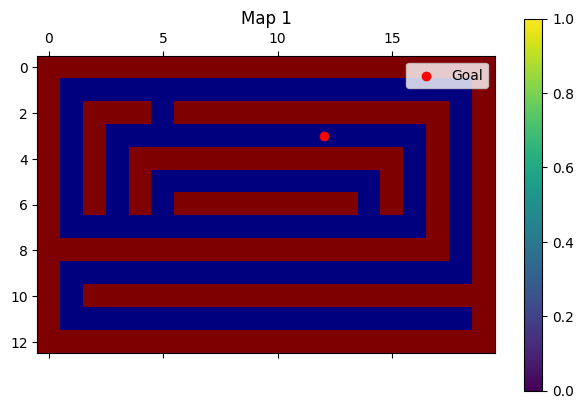

In [ ]:
# User input to choose the map
map_choice = int(input("Enter 1 to select Map 1 or 2 to select Map 2: "))
grid_map, goal = display_map(map_choice)
#goal=(3,12)

# Initialize environment and agent
env = MapEnv(grid_map, goal, max_steps)
agent = QLearning(env, alpha, gamma, epsilon, n_episodes)


Episode 100/10000, Average Reward: -37.62
Episode 200/10000, Average Reward: -18.90
Episode 300/10000, Average Reward: -9.67
Episode 400/10000, Average Reward: -9.12
Episode 500/10000, Average Reward: -5.88
Episode 600/10000, Average Reward: -5.45
Episode 700/10000, Average Reward: -3.46
Episode 800/10000, Average Reward: -3.46
Episode 900/10000, Average Reward: -3.09
Episode 1000/10000, Average Reward: -2.55
Episode 1100/10000, Average Reward: -2.97
Episode 1200/10000, Average Reward: -2.96
Episode 1300/10000, Average Reward: -2.08
Episode 1400/10000, Average Reward: -1.96
Episode 1500/10000, Average Reward: -2.13
Episode 1600/10000, Average Reward: -1.88
Episode 1700/10000, Average Reward: -1.73
Episode 1800/10000, Average Reward: -1.70
Episode 1900/10000, Average Reward: -1.89
Episode 2000/10000, Average Reward: -1.97
Episode 2100/10000, Average Reward: -1.54
Episode 2200/10000, Average Reward: -1.98
Episode 2300/10000, Average Reward: -1.83
Episode 2400/10000, Average Reward: -1.54

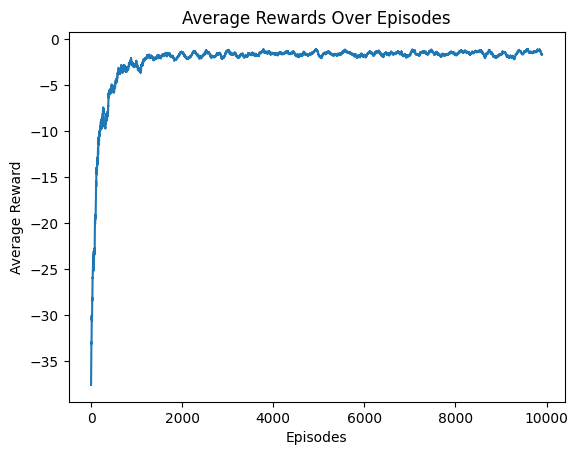

In [23]:
# Create an environment and a QLearning agent to learn it. Plot the averaged rewards stored.
...

'''1q_learning_.ipynb# Training and testing parameters
alpha = 0.1
gamma = 0.9
epsilon = 0.1
n_episodes = 10000
max_steps = 1000
'''
# Training and testing parameters
alpha = float(input("Enter the learning rate (alpha): "))
gamma = float(input("Enter the discount factor (gamma): "))
epsilon = float(input("Enter the initial exploration rate (epsilon): "))
n_episodes = int(input("Enter the number of episodes: "))
max_steps = int(input("Enter the maximum number of steps per episode: "))


env = MapEnv(grid_map, goal, max_steps)
agent = QLearning(env, alpha, gamma, epsilon, n_episodes)

# Train the agent
rewards = agent.train(n_episodes)

# Plot averaged rewards
plt.plot(np.convolve(rewards, np.ones(100)/100, mode='valid'))
plt.title("Average Rewards Over Episodes")
plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.show()

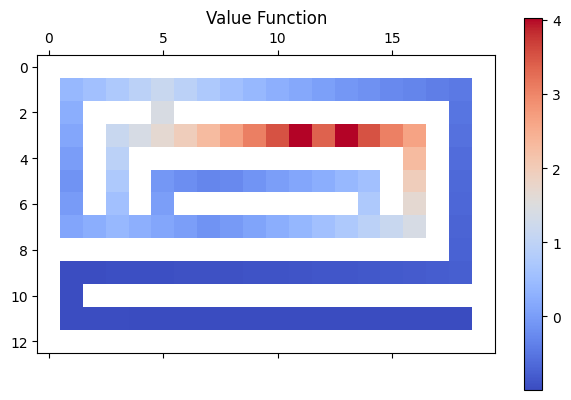

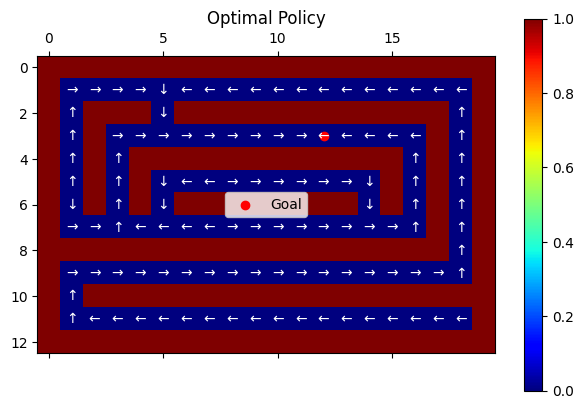

In [24]:
# Plot the value function (see included figure)
...
# Plot value function
value_function = agent.value_function()
plt.matshow(value_function, cmap="coolwarm")
plt.colorbar()
plt.title("Value Function")
plt.show()


# Plot policy (see included figure)
...
# Plot optimal policy on the map
optimal_policy = agent.get_optimal_policy()
policy_arrows = {0: "↑", 1: "↓", 2: "←", 3: "→"}

plt.matshow(grid_map, cmap="jet")
for i in range(optimal_policy.shape[0]):
    for j in range(optimal_policy.shape[1]):
        if optimal_policy[i, j] != -1:  # Not an obstacle
            plt.text(j, i, policy_arrows[optimal_policy[i, j]], ha='center', va='center', color='white')
plt.title("Optimal Policy")
plt.colorbar()
plt.scatter(goal[1], goal[0], color="red", label="Goal")
plt.legend()
plt.show()

In [18]:
from IPython.display import HTML
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def generate_animation(env, optimal_policy, goal):
    """
    Generates an animation showing the agent solving the environment using the optimal policy.
    
    Args:
        env: The environment instance.
        optimal_policy: A 2D array of the optimal policy.
        goal: The coordinates of the goal state (row, col).
    
    Returns:
        HTML: An HTML animation object.
    """
    fig, ax = plt.subplots()

    # Initialize the environment
    state = env.reset()
    path = [state]  # Track the path taken by the agent
    done = False

    # Generate the path following the optimal policy
    while not done:
        action = optimal_policy[state[0], state[1]]
        next_state, _, done = env.step(action)
        path.append(next_state)
        state = next_state

    def update(frame):
        """Update function for each frame in the animation."""
        ax.clear()
        ax.matshow(env.map, cmap="jet")
        ax.scatter(goal[1], goal[0], c='r', label="Goal")
        ax.scatter(path[frame][1], path[frame][0], c='g', label="Agent")
        ax.set_title("Agent Solving the Maze")
        ax.legend()
        ax.set_xticks([])
        ax.set_yticks([])

        # Overlay the optimal policy arrows
        for i in range(optimal_policy.shape[0]):
            for j in range(optimal_policy.shape[1]):
                if optimal_policy[i, j] != -1:  # Not an obstacle
                    ax.text(j, i, policy_arrows[optimal_policy[i, j]], ha='center', va='center', color='white')

    ani = animation.FuncAnimation(fig, update, frames=len(path), interval=500, repeat=False)
    plt.close(fig)  # Prevent the static plot from displaying
    return HTML(ani.to_jshtml())

# Generate the animation
animation_html = generate_animation(env, optimal_policy, goal)
animation_html


## Submission

You must deliver this Python Interactive Notebook. The file must have the name q_learning_YOUR_NAME.ipynb. Also, you must do a report commenting the problems you encountered, a discussion on how the parameters affect the training and conclusions for the results obtained.

Make sure that all cells can be executed.